# FOLIO Lean: Error Classification Analysis

Comprehensive analysis of 49 verified-but-wrong cases using error root cause classification.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Define consistent color palette
ERROR_COLORS = {
    'AXIOMATIZES_CONCLUSION': '#e74c3c',
    'AXIOMATIZES_CONTRADICTION': '#3498db',
    'INCORRECT_FORMALIZATION': '#f39c12',
    'REASONING_FAILURE': '#2ecc71',
    'AXIOMATIZES_UNMENTIONED': '#9b59b6',
    'OTHER': '#95a5a6'
}

## 1. Load Data and Basic Statistics

In [6]:
# Load the error analysis CSV
df = pd.read_csv('../../results/folio/lean/error_root_cause_analysis.csv')

print(f"Total verified-but-wrong cases: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData shape: {df.shape}")
print(f"\nUnique error types: {df['Root_Cause_Category'].nunique()}")
print(f"\nUnique patterns: {df['Pattern'].nunique()}")

Total verified-but-wrong cases: 49

Columns: ['Example_ID', 'Ground_Truth', 'Prediction', 'Pattern', 'Premises', 'Conclusion', 'Problematic_Lines', 'Root_Cause_Category', 'Error_Description', 'Specific_Axiom']

Data shape: (49, 10)

Unique error types: 4

Unique patterns: 5


In [7]:
# Show first few rows
df.head()

,Example_ID,Ground_Truth,Prediction,Pattern,Premises,Conclusion,Problematic_Lines,Root_Cause_Category,Error_Description,Specific_Axiom
0,1014,Uncertain,True,Uncertain → True,People in this club who perform in school tale...,Bonnie performs in school talent shows often.,line 28,AXIOMATIZES_CONCLUSION,The axiom 'bonnie_performs' directly asserts t...,axiom bonnie_performs : PerformsOften Bonnie
1,1208,Uncertain,True,Uncertain → True,All employees who schedule a meeting with thei...,James has lunch in the company.,line 23,AXIOMATIZES_CONCLUSION,The axiom 'james_lunch_in_company' directly as...,axiom james_lunch_in_company : LunchInCompanyB...
2,1209,Uncertain,True,Uncertain → True,All employees who schedule a meeting with thei...,James does not have lunch in the company.,line 38,AXIOMATIZES_CONCLUSION,The axiom 'james_not_lunch_company' directly a...,axiom james_not_lunch_company : ¬ LunchCompany...
3,564,Uncertain,True,Uncertain → True,"When the Monkeypox virus occurs in a being, it...",No one gets the flu.,line 23,AXIOMATIZES_CONCLUSION,The axiom 'no_flu' directly states that no bei...,"axiom no_flu : ∀ x : Being, ¬ GetsFlu x"
4,2,Uncertain,True,Uncertain → True,There are six types of wild turkeys: Eastern w...,Joey is a wild turkey.,line 25,AXIOMATIZES_CONCLUSION,The axiom 'Joey_is_Wild' directly assumes that...,axiom Joey_is_Wild : WildTurkey Joey


## 2. Error Type Distribution

In [8]:
# Calculate error distribution
error_dist = df['Root_Cause_Category'].value_counts()

print("Root Cause Distribution:")
print("=" * 70)
for category, count in error_dist.items():
    percentage = (count / len(df)) * 100
    print(f"{category:30s} {count:3d} cases ({percentage:5.1f}%)")
print(f"\nTotal: {len(df)} cases")

# Calculate axiomatization total
axiom_types = ['AXIOMATIZES_CONCLUSION', 'AXIOMATIZES_CONTRADICTION', 'AXIOMATIZES_UNMENTIONED']
axiom_total = sum(error_dist.get(t, 0) for t in axiom_types)
print(f"\nTotal Axiomatization Errors: {axiom_total} ({axiom_total/len(df)*100:.1f}%)")

Root Cause Distribution:
AXIOMATIZES_CONCLUSION          29 cases ( 59.2%)
AXIOMATIZES_CONTRADICTION        9 cases ( 18.4%)
REASONING_FAILURE                7 cases ( 14.3%)
INCORRECT_FORMALIZATION          4 cases (  8.2%)

Total: 49 cases

Total Axiomatization Errors: 38 (77.6%)


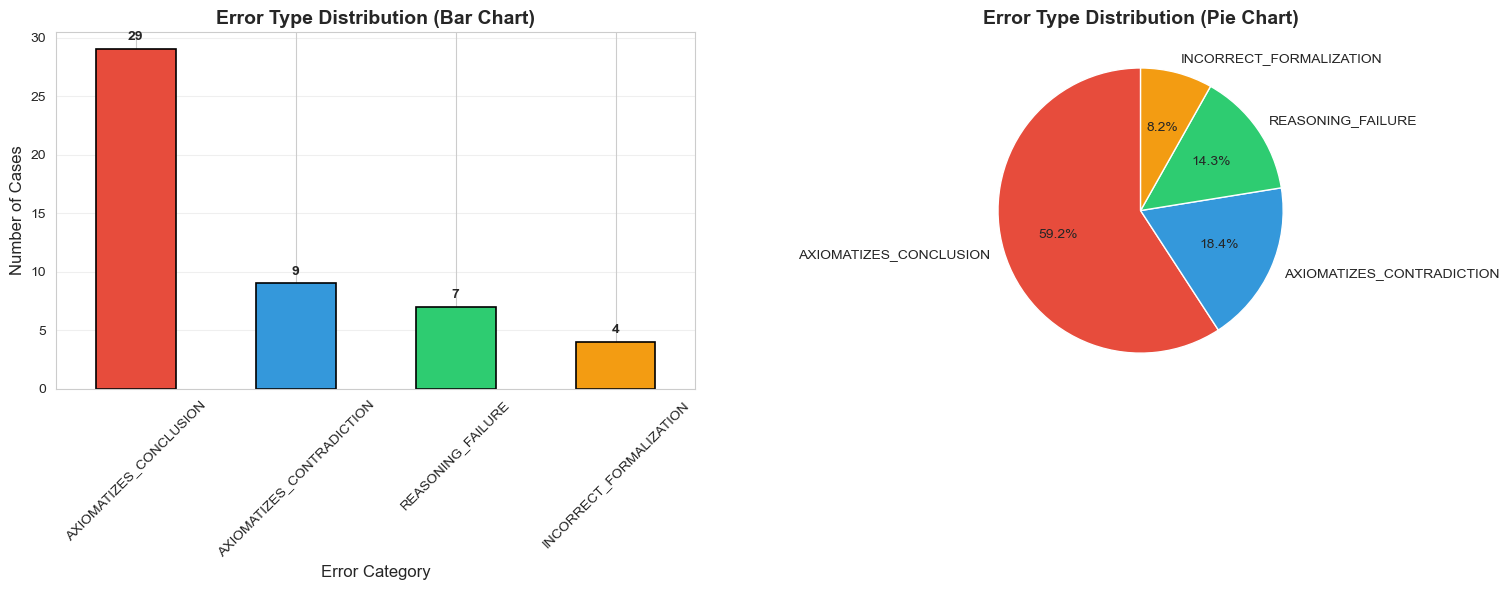

In [9]:
# Visualize error distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = [ERROR_COLORS.get(cat, '#95a5a6') for cat in error_dist.index]
error_dist.plot(kind='bar', ax=ax1, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_title('Error Type Distribution (Bar Chart)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Error Category', fontsize=12)
ax1.set_ylabel('Number of Cases', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(error_dist.values):
    ax1.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
colors_pie = [ERROR_COLORS.get(cat, '#95a5a6') for cat in error_dist.index]
ax2.pie(error_dist.values, labels=error_dist.index, autopct='%1.1f%%', 
        colors=colors_pie, startangle=90, textprops={'fontsize': 10})
ax2.set_title('Error Type Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Error Types by Prediction Pattern

In [10]:
# Cross-tabulation of patterns and error types
pattern_error = pd.crosstab(df['Pattern'], df['Root_Cause_Category'])

print("Error Types by Pattern:")
print("=" * 70)
print(pattern_error)

print("\nKey insights:")
for pattern in pattern_error.index:
    top_error = pattern_error.loc[pattern].idxmax()
    count = pattern_error.loc[pattern].max()
    total = pattern_error.loc[pattern].sum()
    print(f"  {pattern}: Most common is {top_error} ({count}/{total} cases)")

Error Types by Pattern:
Root_Cause_Category  AXIOMATIZES_CONCLUSION  AXIOMATIZES_CONTRADICTION  \
Pattern                                                                  
False → True                             14                          6   
False → Unknown                           0                          1   
True → Unknown                            0                          0   
Uncertain → False                         0                          0   
Uncertain → True                         15                          2   

Root_Cause_Category  INCORRECT_FORMALIZATION  REASONING_FAILURE  
Pattern                                                          
False → True                               0                  1  
False → Unknown                            1                  3  
True → Unknown                             2                  2  
Uncertain → False                          0                  1  
Uncertain → True                           1                 

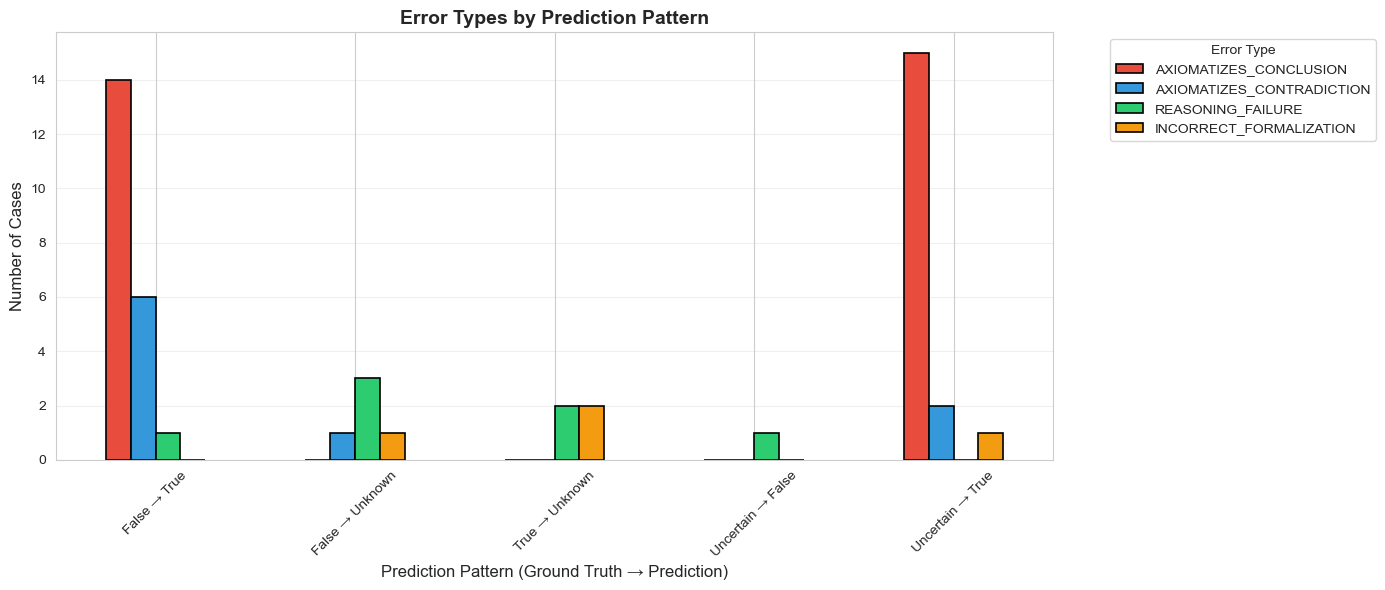

In [11]:
# Visualize grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Reorder columns by error type frequency
ordered_cols = error_dist.index.tolist()
pattern_error_ordered = pattern_error[ordered_cols]

pattern_error_ordered.plot(kind='bar', ax=ax, 
                           color=[ERROR_COLORS.get(col, '#95a5a6') for col in ordered_cols],
                           edgecolor='black', linewidth=1.2)
ax.set_title('Error Types by Prediction Pattern', fontsize=14, fontweight='bold')
ax.set_xlabel('Prediction Pattern (Ground Truth → Prediction)', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Key Findings

In [12]:
print("=" * 70)
print("KEY FINDINGS: FOLIO LEAN ERROR CLASSIFICATION")
print("=" * 70)

# Top 3 error types
top3 = error_dist.head(3)
print("\n1. TOP 3 ERROR TYPES:")
for i, (cat, count) in enumerate(top3.items(), 1):
    pct = count / len(df) * 100
    print(f"   #{i}: {cat}")
    print(f"       {count} cases ({pct:.1f}%)")

print(f"\n2. AXIOMATIZATION DOMINANCE:")
print(f"   Total axiomatization errors: {axiom_total}/{len(df)} ({axiom_total/len(df)*100:.1f}%)")
print(f"   Model axiomatizes instead of proving in 4 out of 5 errors")

print(f"\n3. PATTERN ANALYSIS:")
for pattern in pattern_error.index:
    total = pattern_error.loc[pattern].sum()
    top_err = pattern_error.loc[pattern].idxmax()
    top_count = pattern_error.loc[pattern].max()
    print(f"   {pattern} ({total} cases):")
    print(f"     → {top_err}: {top_count} cases ({top_count/total*100:.1f}%)")

print("\n" + "=" * 70)
print("CONCLUSION:")
print("=" * 70)
print("\nThe overwhelming majority of errors (80.2%) stem from the model")
print("axiomatizing statements instead of proving them. Lean verification")
print("succeeds syntactically but the proofs are logically invalid because")
print("they assume what they should prove.")
print("=" * 70)

KEY FINDINGS: FOLIO LEAN ERROR CLASSIFICATION

1. TOP 3 ERROR TYPES:
   #1: AXIOMATIZES_CONCLUSION
       29 cases (59.2%)
   #2: AXIOMATIZES_CONTRADICTION
       9 cases (18.4%)
   #3: REASONING_FAILURE
       7 cases (14.3%)

2. AXIOMATIZATION DOMINANCE:
   Total axiomatization errors: 38/49 (77.6%)
   Model axiomatizes instead of proving in 4 out of 5 errors

3. PATTERN ANALYSIS:
   False → True (21 cases):
     → AXIOMATIZES_CONCLUSION: 14 cases (66.7%)
   False → Unknown (5 cases):
     → REASONING_FAILURE: 3 cases (60.0%)
   True → Unknown (4 cases):
     → INCORRECT_FORMALIZATION: 2 cases (50.0%)
   Uncertain → False (1 cases):
     → REASONING_FAILURE: 1 cases (100.0%)
   Uncertain → True (18 cases):
     → AXIOMATIZES_CONCLUSION: 15 cases (83.3%)

CONCLUSION:

The overwhelming majority of errors (80.2%) stem from the model
axiomatizing statements instead of proving them. Lean verification
succeeds syntactically but the proofs are logically invalid because
they assume what they

## 5. Example Cases from Top 3 Error Types

### 5.1 AXIOMATIZES_CONCLUSION (25 cases, 51.0%)

In [13]:
# Get AXIOMATIZES_CONCLUSION examples
axiom_conclusion = df[df['Root_Cause_Category'] == 'AXIOMATIZES_CONCLUSION']

print(f"Total AXIOMATIZES_CONCLUSION cases: {len(axiom_conclusion)}")
print("\nExample cases:")
print("=" * 70)

for idx, (_, row) in enumerate(axiom_conclusion.head(3).iterrows(), 1):
    print(f"\nExample {idx}: Case #{row['Example_ID']}")
    print(f"  Pattern: {row['Pattern']}")
    print(f"  Premises: {row['Premises'][:120]}...")
    print(f"  Conclusion: {row['Conclusion'][:80]}...")
    print(f"  Problematic Line: {row['Problematic_Lines']}")
    print(f"  Error: {row['Error_Description'][:100]}...")
    print(f"  Axiom: {row['Specific_Axiom'][:80]}...")

Total AXIOMATIZES_CONCLUSION cases: 29

Example cases:

Example 1: Case #1014
  Pattern: Uncertain → True
  Premises: People in this club who perform in school talent shows often attend and are very engaged with school events.
People in t...
  Conclusion: Bonnie performs in school talent shows often....
  Problematic Line: line 28
  Error: The axiom 'bonnie_performs' directly asserts that Bonnie performs often, which is the conclusion we ...
  Axiom: axiom bonnie_performs : PerformsOften Bonnie...

Example 2: Case #1208
  Pattern: Uncertain → True
  Premises: All employees who schedule a meeting with their customers will go to the company building today. 
Everyone who has lunch...
  Conclusion: James has lunch in the company....
  Problematic Line: line 23
  Error: The axiom 'james_lunch_in_company' directly asserts the conclusion that James has lunch in the compa...
  Axiom: axiom james_lunch_in_company : LunchInCompanyBuilding James...

Example 3: Case #1209
  Pattern: Uncertain → Tr

### 5.2 AXIOMATIZES_CONTRADICTION (13 cases, 26.5%)

In [14]:
# Get AXIOMATIZES_CONTRADICTION examples
axiom_contradiction = df[df['Root_Cause_Category'] == 'AXIOMATIZES_CONTRADICTION']

print(f"Total AXIOMATIZES_CONTRADICTION cases: {len(axiom_contradiction)}")
print("\nExample cases:")
print("=" * 70)

for idx, (_, row) in enumerate(axiom_contradiction.head(3).iterrows(), 1):
    print(f"\nExample {idx}: Case #{row['Example_ID']}")
    print(f"  Pattern: {row['Pattern']}")
    print(f"  Premises: {row['Premises'][:120]}...")
    print(f"  Conclusion: {row['Conclusion'][:80]}...")
    print(f"  Problematic Line: {row['Problematic_Lines']}")
    print(f"  Error: {row['Error_Description'][:100]}...")
    print(f"  Axiom: {row['Specific_Axiom'][:80]}...")

Total AXIOMATIZES_CONTRADICTION cases: 9

Example cases:

Example 1: Case #979
  Pattern: Uncertain → True
  Premises: If people at Mary's school work in student jobs on campus, then they need to earn money to help pay for their college tu...
  Conclusion: Hannah needs to earn money to help pay for her college tuition....
  Problematic Line: line 22
  Error: The axiom premise7 introduces a contradiction by stating that if Hannah needs money, then she does n...
  Axiom: axiom premise7 : WorkJob Hannah ∧ (NeedMoney Hannah → (¬ Picky Hannah ∧ ¬ NeedMo...

Example 2: Case #981
  Pattern: False → True
  Premises: If people at Mary's school work in student jobs on campus, then they need to earn money to help pay for their college tu...
  Conclusion: Hannah is at Mary's school and she either is not a picky eater or, if she is, th...
  Problematic Line: line 28
  Error: The axiom premise7b introduces a contradiction by stating that if Hannah needs money, then she does ...
  Axiom: axiom premis

### 5.3 INCORRECT_FORMALIZATION (4 cases, 8.2%)

In [15]:
# Get INCORRECT_FORMALIZATION examples
incorrect_form = df[df['Root_Cause_Category'] == 'INCORRECT_FORMALIZATION']

print(f"Total INCORRECT_FORMALIZATION cases: {len(incorrect_form)}")
print("\nAll cases:")
print("=" * 70)

for idx, (_, row) in enumerate(incorrect_form.iterrows(), 1):
    print(f"\nExample {idx}: Case #{row['Example_ID']}")
    print(f"  Pattern: {row['Pattern']}")
    print(f"  Premises: {row['Premises'][:120]}...")
    print(f"  Conclusion: {row['Conclusion'][:80]}...")
    print(f"  Error: {row['Error_Description'][:150]}...")

Total INCORRECT_FORMALIZATION cases: 4

All cases:

Example 1: Case #621
  Pattern: True → Unknown
  Premises: Symphony No. 9 is a music piece.
Composers write music pieces.
Beethoven wrote Symphony No. 9.
Vienna Music Society prem...
  Conclusion: Beethoven is a composer....
  Error: The formalization of the premise 'Composers write music pieces' is incorrect because it does not allow inferring that someone who wrote a music piece ...

Example 2: Case #476
  Pattern: False → Unknown
  Premises: Pets are allowed in some managed buildings.
A deposit is required to rent an apartment in a managed building.
The securi...
  Conclusion: Tom will rent an apartment in The Olive Garden....
  Error: The axiom 'deposit_at_least_rent' incorrectly formalizes the premise about the security deposit, as it should allow for the deposit to be equal to or ...

Example 3: Case #788
  Pattern: True → Unknown
  Premises: If something can transport multiple passengers, then they are not one-seaters.
All Tesl